### parameters

In [1]:
L            = 3 # number of sites (number of qubits = 2 * number of sites)
nq           = 2*L # total number of qubits
nq_1site     = 2 # number of qubits per site
J1,J2,J3,J4  = [1/2,1/2,1/2,1] # Hamiltonian parameters
dt           = 0.1 # time duration trotter step
ini          = '0'*nq # initial state
Ntrotter_max = 10 # number of trotter 
phi_max      = 1
delta_phi    = 2*phi_max/(2**nq_1site -1)
MPSthreshold = 1e-8
Nshots       = int(1e4)

In [2]:
%matplotlib inline

### main definitions

In [3]:
from qiskit import QuantumCircuit
from qiskit.quantum_info import Operator
from qiskit.circuit.library import QFTGate
import numpy as np
from qiskit_aer.backends.aer_simulator import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
from scipy.linalg import expm

In [4]:
def Upi_wall(qc, nq, J1, tau): # Upi_wall = sum_j Upi_j (require quantum fourier transform)
    # Upi_j = exp( -i (tau J1 pi^2 / (4 delta_phi^2) ) Z_{2j} Z_{2j+1} )
    # RZZ(theta) = exp( -i (theta / 2) Z_i Z_j)
    theta = 2*tau*J1*np.pi**2 / (4*delta_phi**2)
    for j in range(L):
        qc.compose(QFTGate(2), qubits=[2*j, 2*j+1], inplace=True)
        qc.rzz(theta,2*j,2*j+1)
        qc.compose(QFTGate(2).inverse(), qubits=[2*j, 2*j+1], inplace=True)

In [5]:
def Uphi_wall(qc, nq, J2, J3, J4, tau): # Uphi_wall = sum_j Uphi_j
    # Uphi_j has 6 terms, Uphi_j = exp(- i tau [
    # Z_{2j}   Z_{2j+1} (J2 ( 4 phi_max^2 / 9) + J3 (4 phi_max^2 / 9) + J4 (40 phi_max^4 / 81) ) +  --> 0q between
    # Z_{2j+1} Z_{2j+2} (J3 (-4 phi_max^2 / 9) ) +   --> 0q between
    # Z_{2j+2} Z_{2j+3} (J3 ( 4 phi_max^2 / 9) ) +   --> 0q between
    # Z_{2j}   Z_{2j+2} (J3 (-2 phi_max^2 / 9) ) +   --> 1q between
    # Z_{2j+1} Z_{2j+3} (J3 (-8 phi_max^2 / 9) ) +   --> 1q between
    # Z_{2j}   Z_{2j+3} (J3 (-4 phi_max^2 / 9) ) ] ) --> 2q between
    # RZZ(theta) = exp( -i (theta / 2) Z_i Z_j)
    
    # 1. qubits next to each other
    theta1 = 2*tau*J2*( 4*phi_max**2 / 9) + J3*(4*phi_max**2 / 9) + J4*(40*phi_max**4 / 81)
    theta2 = 2*tau*J3*(-4*phi_max**2 / 9)
    theta3 = 2*tau*J3*( 4*phi_max**2 / 9)
    def theta_even_odd(j):
        theta = 0
        if j%2==0:
            theta += theta1
        else:
            theta += theta2
        if j%2==0 and j>=2:
            theta += theta3
        return theta
    for j in range(0, nq-1, 2):
        qc.rzz(theta_even_odd(j), j, j+1)
    for j in range(1, nq-1, 2):
        qc.rzz(theta_even_odd(j), j, j+1)
    
    # 2. qubits with 1 site between them
    theta_even = 2*tau*J3*(-2)*phi_max**2 / 9
    theta_odd  = 2*tau*J3*(-8)*phi_max**2 / 9
    def theta_even_odd(j):
        if j%2==0:
            return theta_even
        else:
            return theta_odd
    for j in range(0,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    for j in range(1,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    for j in range(2,nq-2,3):
        qc.rzz(theta_even_odd(j), j, j+2)
    
    # 3. qubits with 2 sites between them
    theta = 2*tau*J3*(-4)*phi_max**2 / 9
    for j in range(0, nq-3, 4):
        qc.rzz(theta, j, j+3)
    for j in range(2, nq-3, 4):
        qc.rzz(theta, j, j+3)

In [6]:
def trotter_step1(qc, nq, J1, J2, J3, J4, tau):
    # implements 1st order trotter
    Upi_wall(qc, nq, J1, tau)    
    Uphi_wall(qc, nq, J2, J3, J4, tau)    

def trotter_step2(qc, nq, J1, J2, J3, J4, tau):
    # implements second order trotter step. 
    Uphi_wall(qc, nq, J2, J3, J4, tau/2) # tau/2 in Uphi because second order trotter  step
    Upi_wall(qc, nq, J1, tau)
    Uphi_wall(qc, nq, J2, J3, J4, tau/2) # tau/2 in Uphi because second order trotter  step

In [7]:
# this print all useful information of a quantum circuit, I got it from an IBM tutorial and updated using chatGPT
def info_qc(qc_temp):
    depth2q = 0
    qubit_busy = {}

    qubit_indices = {qubit: idx for idx, qubit in enumerate(qc_temp.qubits)}

    for inst in qc_temp.data:
        qargs = inst.qubits
        if len(qargs) == 2:
            idxs = [qubit_indices[q] for q in qargs]
            t = max(qubit_busy.get(i, 0) for i in idxs)
            for i in idxs:
                qubit_busy[i] = t + 1
            depth2q = max(depth2q, t + 1)

    print(f"""
Depth: {qc_temp.depth()}
Two-qubit depth: {depth2q}
Gate count: {len(qc_temp)}
Nonlocal gate count: {qc_temp.num_nonlocal_gates()}
Gate breakdown: {", ".join([f"{k.upper()}: {v}" for k, v in qc_temp.count_ops().items()])}
    """)

### MPS evolution

In [8]:
from qiskit import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.backends.aer_simulator import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2

In [9]:
service = QiskitRuntimeService()
backend_name = 'ibm_basquecountry'
backend = service.backend(backend_name)

In [10]:
backend = AerSimulator(method="matrix_product_state",matrix_product_state_truncation_threshold=MPSthreshold,)
sampler = AerSamplerV2.from_backend(backend,options={"run_options": {"shots": Nshots},},) 

Ntrotter:  1


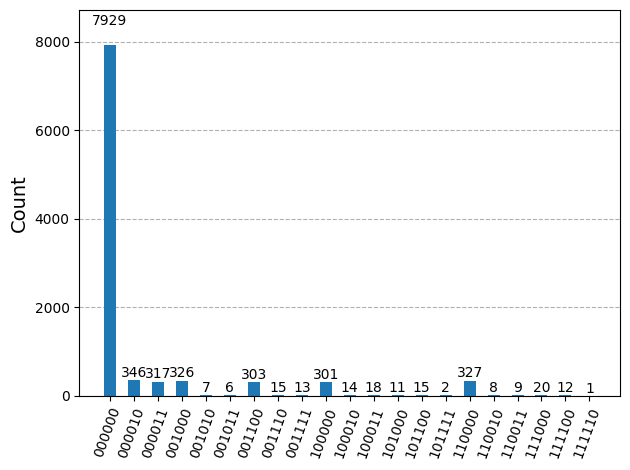

Ntrotter:  2


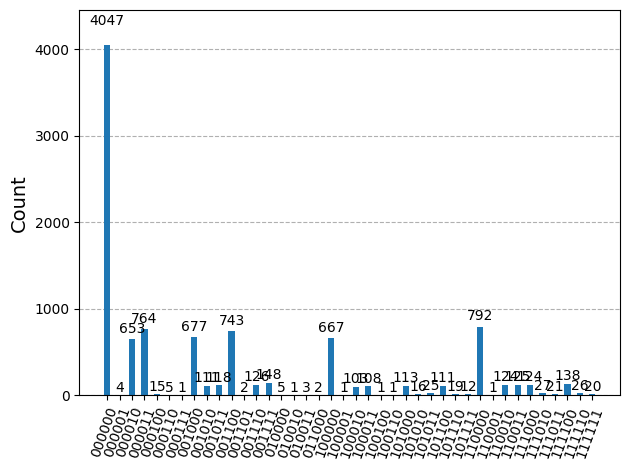

Ntrotter:  3


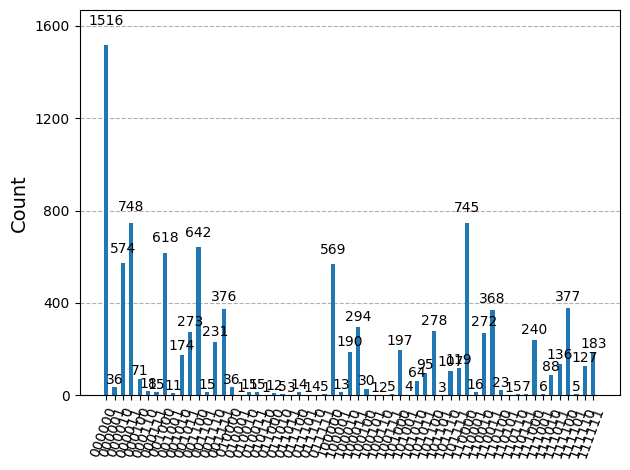

Ntrotter:  4


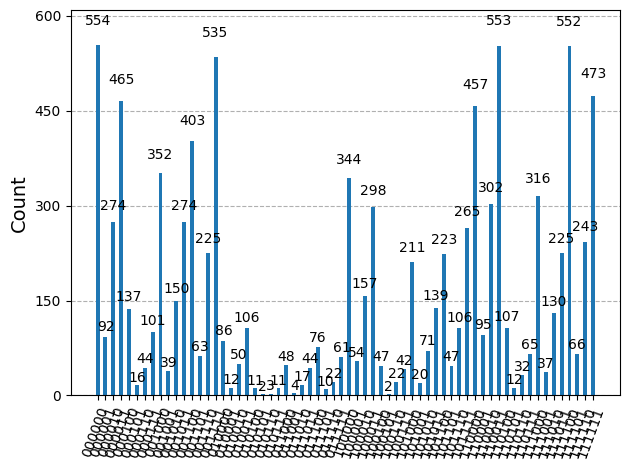

Ntrotter:  5


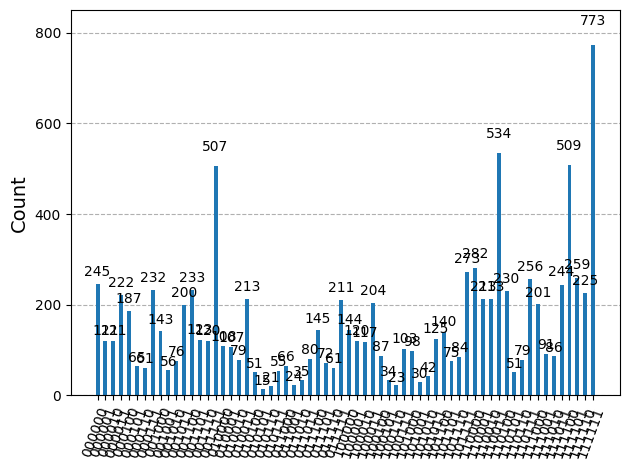

Ntrotter:  6


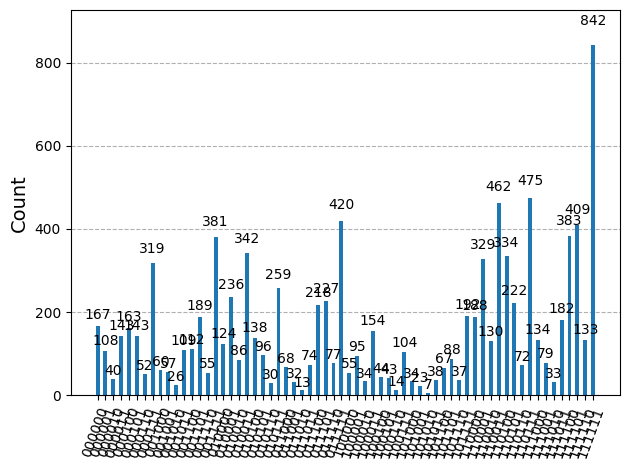

Ntrotter:  7


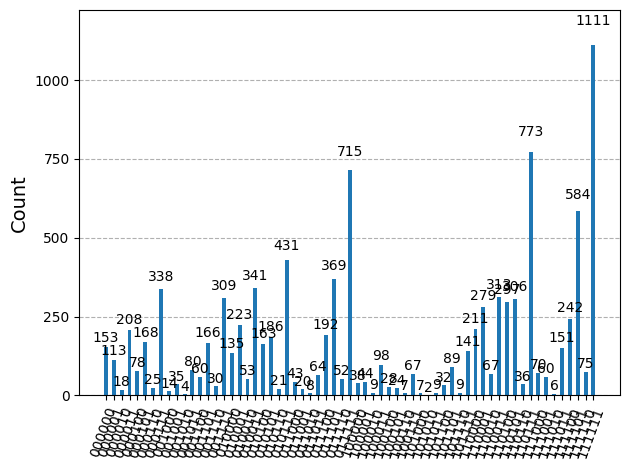

Ntrotter:  8


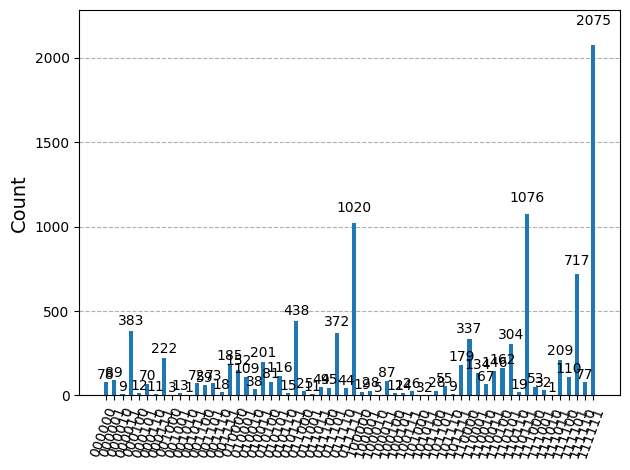

Ntrotter:  9


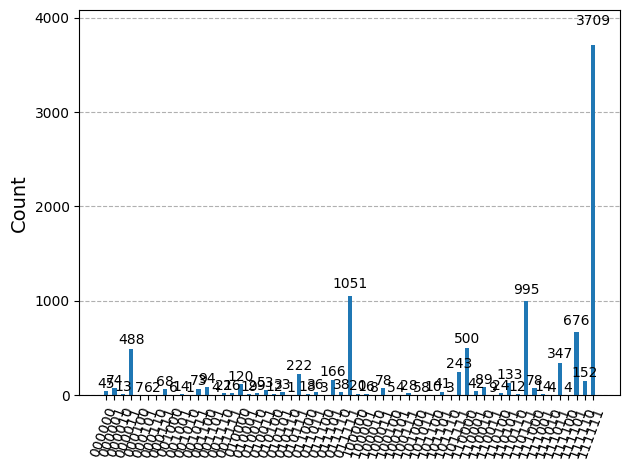

In [ ]:
# perform quantum state evolution using quantum circuits and MPS
MPS_evolution_data = {Ntrotter:{} for Ntrotter in range(1,Ntrotter_max+1)}
MPS_evolution_data[0] = {ini:1} # initial state (time 0)

for Ntrotter in range(1,Ntrotter_max+1):
    qc = QuantumCircuit(nq)
    qc.initialize(ini)
    for n in range(Ntrotter):
        trotter_step1(qc, nq, J1, J2, J3, J4, dt)
    qc.measure_active()

    # this part implements the layout and decomposes the gates we used to define the quantum circuit in native gates of the machine
    layout = [q for q in range(nq)] # maps qubit q of the quantum circuit to the machine qubit number q (not useful here since it is not a real machine)
    pm = generate_preset_pass_manager(backend=backend, optimization_level=3, initial_layout=layout)
    isa_qc = pm.run(qc) # this is now a quantum circuit that we can run in a machine (isa = instruction set architecture)

    # print useful information about isa_qc
    print('Ntrotter: ',Ntrotter)
    #info_qc(isa_qc)
    
    # run the Sampler experiment
    job = sampler.run([isa_qc], shots=Nshots)

    # get counts from the experiment, invert strings (https://quantum.cloud.ibm.com/docs/en/guides/bit-ordering)
    temp   = job.result()[0].data
    counts = temp.meas.get_counts()
    counts = {x[::-1]:counts[x] for x in counts}
    
    MPS_evolution_data[Ntrotter] = counts

    plot_histogram(counts)
    plt.show()

### fake provider with zero noise

In [ ]:
from qiskit import *
from qiskit_ibm_runtime import QiskitRuntimeService
from qiskit_aer.backends.aer_simulator import AerSimulator
from qiskit_aer.primitives import SamplerV2 as AerSamplerV2
from qiskit.providers.fake_provider import GenericBackendV2

In [ ]:
service = QiskitRuntimeService()
backend_name = 'ibm_basquecountry'
backend = service.backend(backend_name)

In [ ]:
# perform quantum state evolution using quantum circuits and a fake backend with zero noise
NoNoise_evolution_data = {Ntrotter:{} for Ntrotter in range(1,Ntrotter_max+1)}
NoNoise_evolution_data[0] = {ini:1} # initial state (time 0)

for Ntrotter in range(1,Ntrotter_max+1):
    qc = QuantumCircuit(nq)
    qc.initialize(ini)
    for n in range(Ntrotter):
        trotter_step1(qc, nq, J1, J2, J3, J4, dt)
    qc.measure_active()

    # Run on FAKE backend
    local_backend = GenericBackendV2(num_qubits=qc.num_qubits, noise_info=False)
    pm            = generate_preset_pass_manager(backend=local_backend, optimization_level=0)
    isa_qc        = pm.run(qc)
    result        = local_backend.run(isa_qc, shots=Nshots).result()
    counts        = result.get_counts()
    counts        = {x[::-1]:counts[x] for x in counts}

    # print useful information about isa_qc
    print('Ntrotter: ',Ntrotter)
    #info_qc(isa_qc)
    
    NoNoise_evolution_data[Ntrotter] = counts

    plot_histogram(counts)
    plt.show()